## Seguiu aquestes instruccions

+ Descarregueu el fitxer .py de la pràctica del Campus Virtual i poseu aquest nom al fitxer: `practica1.py`
+ Executeu la cel·la dels `import`
+ Carregeu les dades dels anys 2019 i 2022.
+ Crea un df amb totes les dades netes i post-processades.

In [1]:
#%pip install pyarrow
#%pip install pandas
#%pip install tqdm
#%pip install matplotlib

In [2]:
import numpy as np
import urllib.request
import zipfile
import os
from tqdm.notebook import tqdm
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

from practica1 import *

In [3]:
# Variables globals: els anys que estudiarem i la conversió milles-km
MILES_TO_KM = 1.60934
YEARS = [2019, 2022]

for year in tqdm(YEARS):
    if not os.path.exists(f'data/{year}'):
        os.makedirs(f'data/{year}', exist_ok=True)
        for month in tqdm(range(1, 13)):
            urllib.request.urlretrieve(f'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{year}-{month:02d}.parquet', f'data/{year}/{month:02d}.parquet')

  0%|          | 0/2 [00:00<?, ?it/s]

In [4]:
df = pd.concat([clean_data(load_table(year, month), year, month)
                for year in tqdm(YEARS)
                for month in tqdm(range(1, 13), leave = False)],
                ignore_index=True, sort=False)
df = post_processing(df)
df.shape

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

(1185329, 24)

## Trieu 2 exercicis d'entre el 3 següents i contesteu-los.

**Exercici 1:** Mesura la **diferència** entre l'any 2019 i l'any 2022 en aquestes temes:

    + Ingressos totals generats per trajectes entre les 18:00 i les 22:00?

**Exercici 2:** Per l'any 2022:
    
    + A quina destinació es gasten més diners de mitjana?


**Exercici 3:** Per l'any 2019:
    
    + Hi ha diferències significatives en la durada dels trajectes en funció de l’hora del dia? Fes una gràfica que ho mostri.


In [10]:
travels_2022 = df[df['year'] == 2022]
travels_2019 = df[df['year'] == 2019]

## Exercici 1

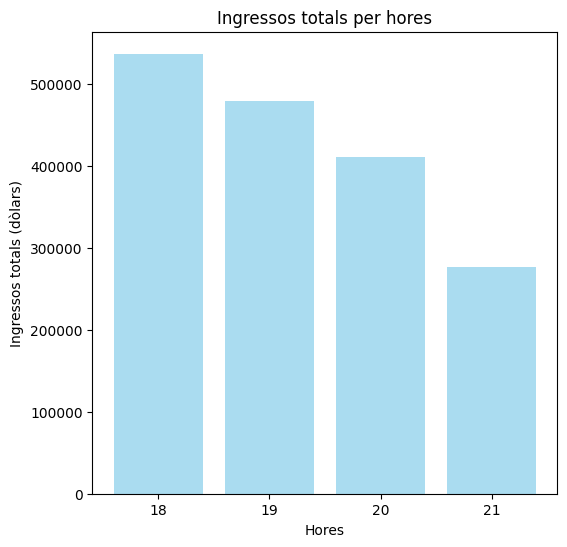

In [6]:
# Exercici 1
filtered_travels_2022 = travels_2022[(travels_2022['pickup_hour'] >= 18) &
                                     (travels_2022['pickup_hour'] <= 21) &
                                     (travels_2022['dropoff_hour'] >= 18) &
                                     (travels_2022['dropoff_hour'] <= 21)]

filtered_travels_2022 = filtered_travels_2022.groupby("pickup_hour")["total_amount"].sum()

plt.figure(figsize=(6,6))
plt.bar(filtered_travels_2022.index, filtered_travels_2022.values, color='skyblue', alpha=0.7)

# Anomenem els eixos segons els valors passats per paràmetre
plt.xlabel("Hores")
plt.ylabel("Ingressos totals (dòlars)")
plt.title("Ingressos totals per hores")
# Mostrem el temps a l'eix x
plt.xticks(filtered_travels_2022.index)
plt.show()


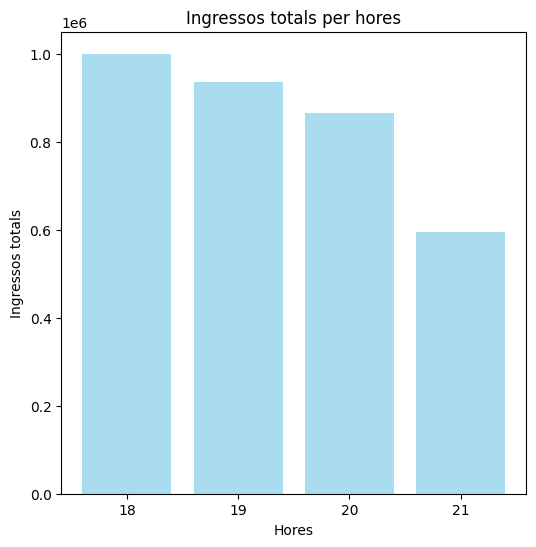

In [7]:
# Exercici 1
filtered_travels_2019 = travels_2019[(travels_2019['pickup_hour'] >= 18) &
                                     (travels_2019['pickup_hour'] <= 21) &
                                     (travels_2019['dropoff_hour'] >= 18) &
                                     (travels_2019['dropoff_hour'] <= 21)]

filtered_travels_2019 = filtered_travels_2019.groupby("pickup_hour")["total_amount"].sum()

plt.figure(figsize=(6,6))
plt.bar(filtered_travels_2019.index, filtered_travels_2019.values, color='skyblue', alpha=0.7)

# Anomenem els eixos segons els valors passats per paràmetre
plt.xlabel("Hores")
plt.ylabel("Ingressos totals")
plt.title("Ingressos totals per hores")
# Mostrem el temps a l'eix x
plt.xticks(filtered_travels_2019.index)
plt.show()


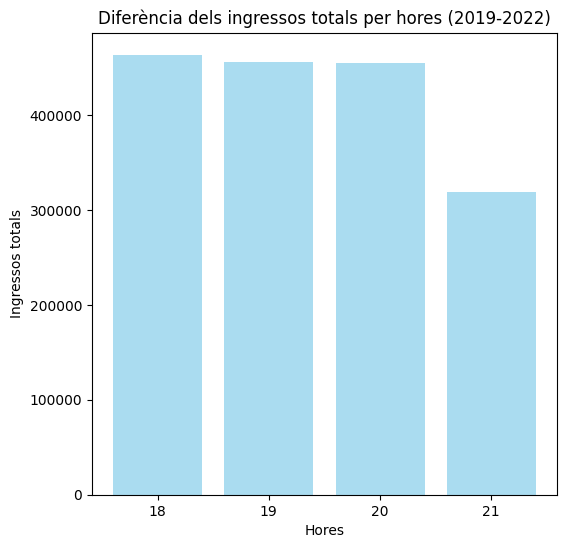

In [8]:
# Veure la diferència
difference = abs(filtered_travels_2022 - filtered_travels_2019)

plt.figure(figsize=(6,6))
plt.bar(difference.index, difference.values, color='skyblue', alpha=0.7)

# Anomenem els eixos segons els valors passats per paràmetre
plt.xlabel("Hores")
plt.ylabel("Ingressos totals")
plt.title("Diferència dels ingressos totals per hores (2019-2022)")
# Mostrem el temps a l'eix x
plt.xticks(difference.index)
plt.show()

És significatiu que la diferència entre els ingressos del 2022 i el 2019 fos similar als ingressos totals del 2019. Això ens diu que d'abans de la pandèmia al 2022 els ingressos han caigut quasi a la meitat. La distribució en ambdós és similar, també, mostrant que els hàbits de transport tampoc no han canviat massa durant aquests anys. Es guanya menys diners a mesura que es va fent tard.

## Exercici 3

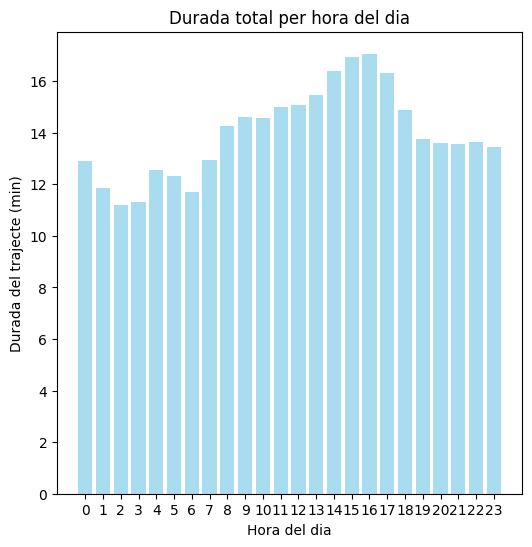

In [9]:
# Multiplico per 60 per veure-ho en minuts
trips = travels_2019.groupby("pickup_hour")["travel_time"].mean() * 60

# Creem el gràfic
plt.figure(figsize=(6,6))
plt.bar(trips.index, trips.values, color='skyblue', alpha=0.7)
# Anomenem els eixos segons els valors passats per paràmetre
plt.xlabel("Hora del dia")
plt.ylabel("Durada del trajecte (min)")
plt.title("Durada total per hora del dia")
# Mostrem el temps a l'eix x
plt.xticks(trips.index)

plt.show()

Són les hores centrals de la tarda (14-17) quan més duren els viatges. La matinada, quan menys. Els factors poden ser molt diversos; per exemple, la fluidesa del trànsit durant la matinada, o la no-fluidesa durant l'hora que la gent acostuma a sortir de treballar. Una vegada s'arriba al pic de la tarda i més cap a la nit, ja no es recupera una durada similar fins ben entrat el matí.